#MULTIPLE LINEAR REGRESSION
Assignment Task:  
Your task is to perform a multiple linear regression analysis to predict the price of Toyota corolla based on the given attributes.
Dataset Description:  
The dataset consists of the following variables:  
Age: Age in years  
KM: Accumulated Kilometers on odometer  
FuelType: Fuel Type (Petrol, Diesel, CNG)  
HP: Horse Power  
Automatic: Automatic ( (Yes=1, No=0)    
CC: Cylinder Volume in cubic centimeters  
Doors: Number of doors  
Weight: Weight in Kilograms  
Quarterly_Tax:   
Price: Offer Price in EUROs  
Tasks:  
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.    
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).  
3.Build a multiple linear regression model using the training dataset.   Interpret the coefficients of the model. Build a minimum of 3 different models.  
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.  
5.Apply Lasso and Ridge methods on the model.  

Interview Questions:  
1.What is Normalization & Standardization and how is it helpful?  
2.What techniques can be used to address multicollinearity in multiple linear regression?  


Ensure to properly comment your code and provide explanations for your analysis.  
Include any assumptions made during the analysis and discuss their implications.  


#notes:
linear regression is a technique to find relation between two variables we are interested in Regression line Best fit line or line of regression. best fit line is basically gives minumum error is the line that we need to consider. in regression we have MSE;RMSE;MAE,R2 score evaluation matrix.

in this assignment the target is price y and the rest are x Age_08_04,	KM,Fuel_Type,	HP,	Automatic,	cc,	Doors,	Cylinders,	Gears,	Weight.

here all x must have individual relationship with y to see that we use scatterplot and statistical measure we check correlation()

whichever models rmse is low and r2_score is hight then they are the bestfit model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


since fueltype is categorical. dataset contains both numerical and categorical value

In [ ]:
df.shape

(1436, 11)

In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace =True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1435 non-null   int64 
 1   Age_08_04  1435 non-null   int64 
 2   KM         1435 non-null   int64 
 3   Fuel_Type  1435 non-null   object
 4   HP         1435 non-null   int64 
 5   Automatic  1435 non-null   int64 
 6   cc         1435 non-null   int64 
 7   Doors      1435 non-null   int64 
 8   Cylinders  1435 non-null   int64 
 9   Gears      1435 non-null   int64 
 10  Weight     1435 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 134.5+ KB


In [ ]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,False,True
1432,10845,72,19000,86,0,1300,3,4,5,1015,False,True
1433,8500,71,17016,86,0,1300,3,4,5,1015,False,True
1434,7250,70,16916,86,0,1300,3,4,5,1015,False,True


In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


In [ ]:
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [ ]:
df.tail()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
1431,7500,69,20544,86,0,1300,3,4,5,1025,False,True
1432,10845,72,19000,86,0,1300,3,4,5,1015,False,True
1433,8500,71,17016,86,0,1300,3,4,5,1015,False,True
1434,7250,70,16916,86,0,1300,3,4,5,1015,False,True
1435,6950,76,1,110,0,1600,5,4,5,1114,False,True


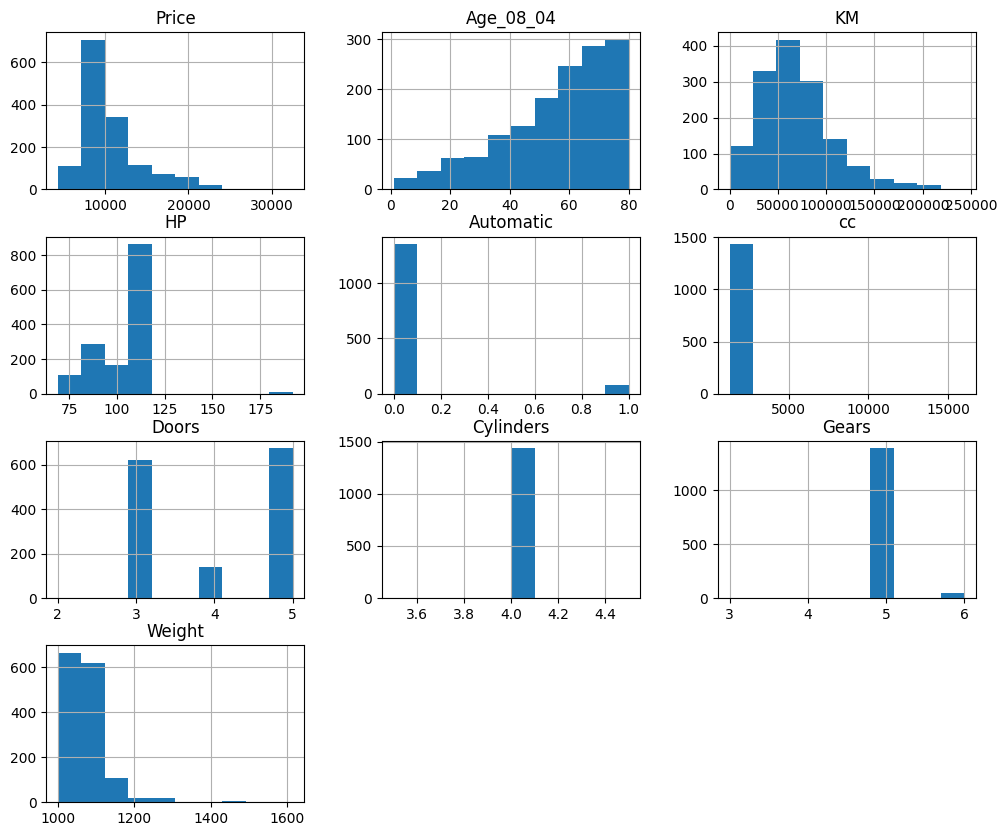

In [ ]:
df.hist(figsize=(12,10))
plt.show()

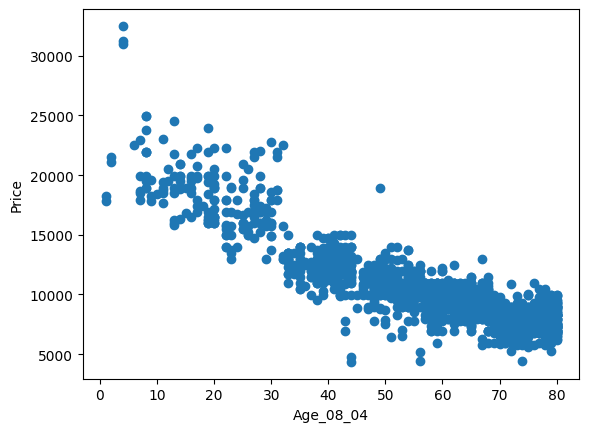

In [ ]:
plt.scatter(x=df['Age_08_04'], y=df['Price'])
plt.xlabel('Age_08_04')
plt.ylabel('Price')
plt.show()

In [ ]:
#the above shows negative but to find it in actual used below code
df[['Age_08_04','Price']].corr()
#strong negative realtionship

,Age_08_04,Price
Age_08_04,1.000000,-0.876273
Price,-0.876273,1.000000


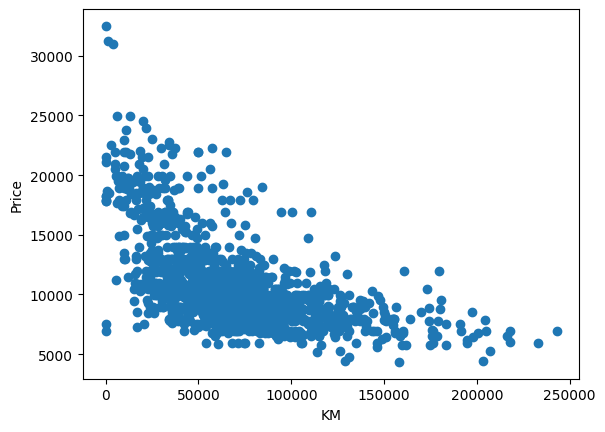

In [ ]:
plt.scatter(x=df['KM'], y=df['Price'])
plt.xlabel('KM')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['KM','Price']].corr()

,KM,Price
KM,1.00000,-0.56942
Price,-0.56942,1.00000


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Fuel_Type_Diesel']=le.fit_transform(df['Fuel_Type_Diesel'])
x_cat=df['Fuel_Type_Diesel']
x_cat

,Fuel_Type_Diesel
0,1
1,1
2,1
3,1
4,1
...,...
1431,0
1432,0
1433,0
1434,0


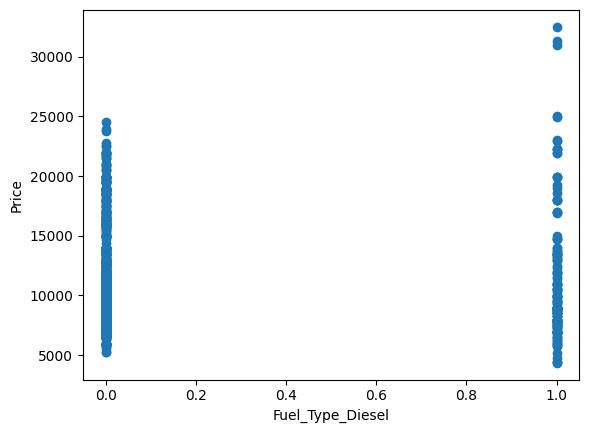

In [ ]:
plt.scatter(x=df['Fuel_Type_Diesel'], y=df['Price'])
plt.xlabel('Fuel_Type_Diesel')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Fuel_Type_Diesel','Price']].corr() # cant find correlation as we need to conver categorical to numerical

,Fuel_Type_Diesel,Price
Fuel_Type_Diesel,1.000000,0.046612
Price,0.046612,1.000000


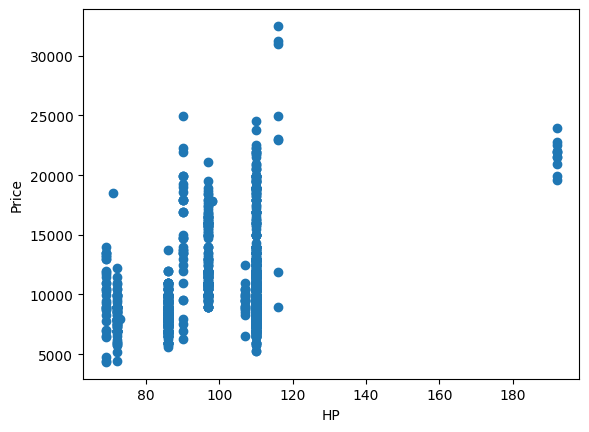

In [ ]:
plt.scatter(x=df['HP'], y=df['Price'])
plt.xlabel('HP')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['HP','Price']].corr()

,HP,Price
HP,1.000000,0.314134
Price,0.314134,1.000000


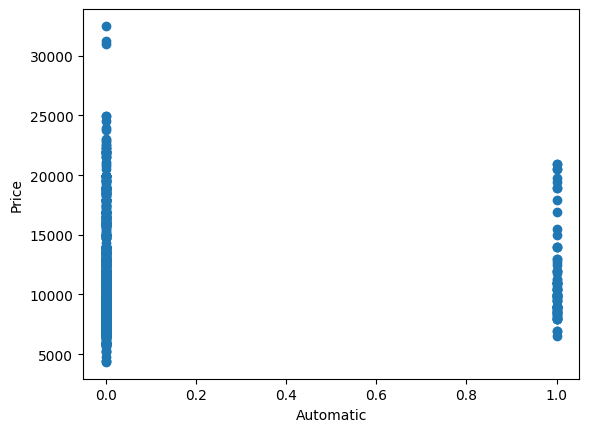

In [ ]:
plt.scatter(x=df['Automatic'], y=df['Price'])
plt.xlabel('Automatic')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Automatic','Price']].corr()

,Automatic,Price
Automatic,1.000000,0.033928
Price,0.033928,1.000000


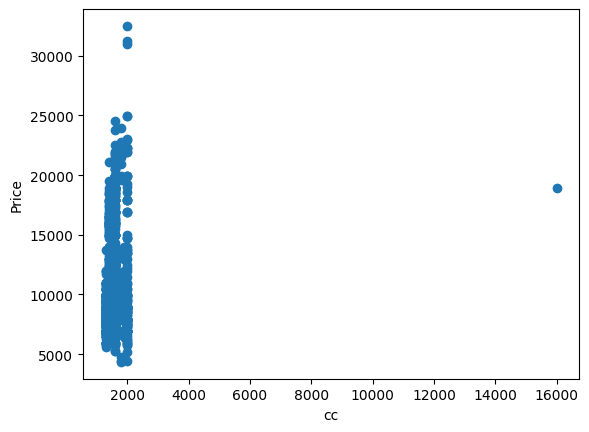

In [ ]:
plt.scatter(x=df['cc'], y=df['Price'])
plt.xlabel('cc')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['cc','Price']].corr()

,cc,Price
cc,1.000000,0.124375
Price,0.124375,1.000000


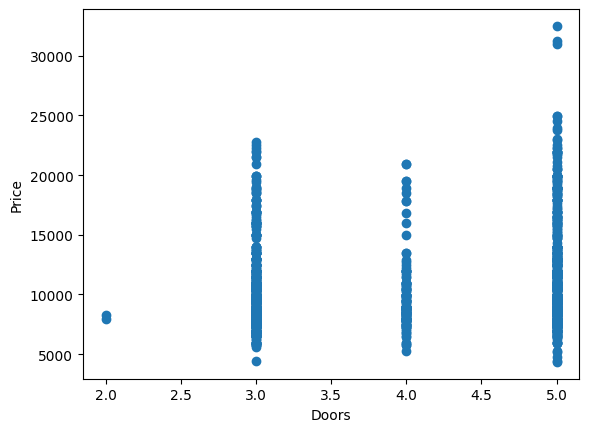

In [ ]:
plt.scatter(x=df['Doors'], y=df['Price'])
plt.xlabel('Doors')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Doors','Price']].corr()

,Doors,Price
Doors,1.000000,0.183604
Price,0.183604,1.000000


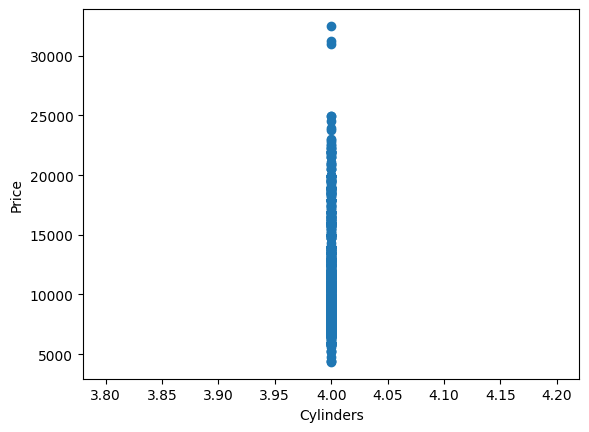

In [ ]:
plt.scatter(x=df['Cylinders'], y=df['Price'])
plt.xlabel('Cylinders')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Cylinders','Price']].corr()

,Cylinders,Price
Cylinders,NaN,NaN
Price,NaN,1.0


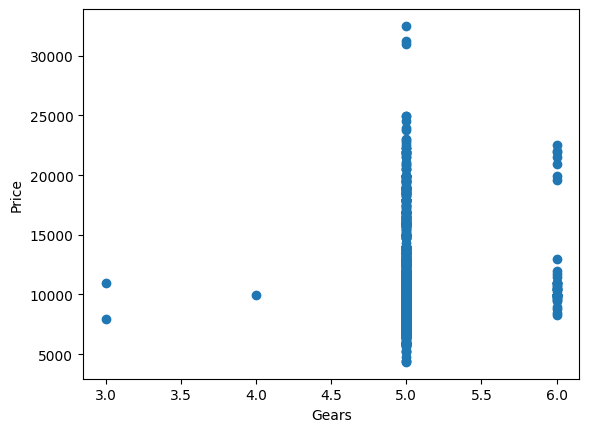

In [ ]:
plt.scatter(x=df['Gears'], y=df['Price'])
plt.xlabel('Gears')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Gears','Price']].corr()

,Gears,Price
Gears,1.000000,0.063831
Price,0.063831,1.000000


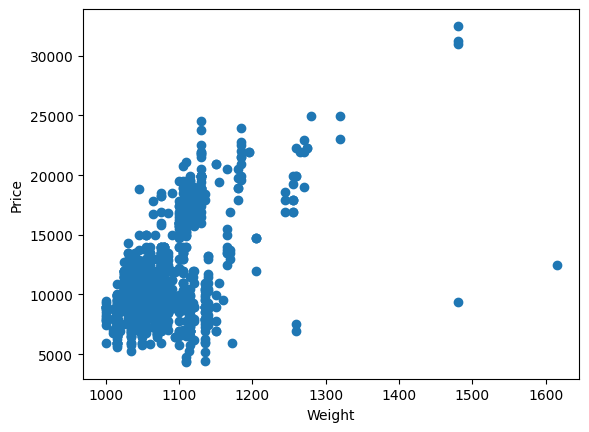

In [ ]:
plt.scatter(x=df['Weight'], y=df['Price'])
plt.xlabel('Weight')
plt.ylabel('Price')
plt.show()

In [ ]:
df[['Weight','Price']].corr()

,Weight,Price
Weight,1.000000,0.575869
Price,0.575869,1.000000


In [ ]:
df.corr() #diagonal values we discard.
#age vs price -0.88
#km vs price -0.56
#fuel_type vs price -0.016
#the above are storng negavtive
#HP vs PRICE is 0:314
#automatic vs price 0.03
#cc vs price 0.12
#cylinders vs price nan
#gears vs price 0.063
#weight vs price 0.578
#the corr is between -1 to  to +1

#Age and KM negatively impact car prices.
#HP and Weight positively impact prices.


#weight>HP>cc>gears>automatic>fuel_type>fm>age

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
Price,1.000000,-0.876273,-0.569420,0.314134,0.033928,0.124375,0.183604,NaN,0.063831,0.575869,0.046612,-0.031356
Age_08_04,-0.876273,1.000000,0.504575,-0.155293,0.031354,-0.096549,-0.146929,NaN,-0.005629,-0.466484,-0.093058,0.088169
KM,-0.569420,0.504575,1.000000,-0.332904,-0.082168,0.103822,-0.035193,NaN,0.014890,-0.023969,0.407497,-0.437397
HP,0.314134,-0.155293,-0.332904,1.000000,0.013313,0.035207,0.091803,NaN,0.209642,0.087143,-0.537116,0.492362
Automatic,0.033928,0.031354,-0.082168,0.013313,1.000000,0.066934,-0.027492,NaN,-0.098582,0.058499,-0.084248,0.079997
cc,0.124375,-0.096549,0.103822,0.035207,0.066934,1.000000,0.079254,NaN,0.014732,0.335077,0.326780,-0.314200
Doors,0.183604,-0.146929,-0.035193,0.091803,-0.027492,0.079254,1.000000,NaN,-0.160101,0.301734,0.023538,-0.025746
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063831,-0.005629,0.014890,0.209642,-0.098582,0.014732,-0.160101,NaN,1.000000,0.021238,-0.048706,0.063079
Weight,0.575869,-0.466484,-0.023969,0.087143,0.058499,0.335077,0.301734,NaN,0.021238,1.000000,0.564649,-0.557315


In [ ]:
# m1=splitting data into X and y:
x = df[["Age_08_04"]]
y = df["Price"]

#model building
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#model fitting
model.fit(x,y)

#model prediction
y_pred=model.predict(x)

# Evaluation metrics (we take accuracy and error)
from sklearn.metrics import r2_score, root_mean_squared_error
score = r2_score(y,y_pred)#always between actual and y predicted
print("R2 Score : ",score)

rmse = root_mean_squared_error(y,y_pred)
print('RMSE:', rmse)

R2 Score :  0.7678550373053038
RMSE: 1738.133002370334


In [ ]:
# m2=splitting data into X and y:
x = df[["Age_08_04", 'KM', 'Weight','HP']]
y = df["Price"]

#model building
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#model fitting
model.fit(x,y)

#model prediction
y_pred=model.predict(x)

# Evaluation metrics
from sklearn.metrics import r2_score, root_mean_squared_error
score = r2_score(y,y_pred)
print("R2 Score : ",score)

rmse = root_mean_squared_error(y,y_pred)
print('RMSE:', rmse)

R2 Score :  0.8605512516617329
RMSE: 1347.133647737924


In [ ]:
#m3= splitting data into X and y:
x = df[["Age_08_04", 'KM', 'Fuel_Type_Diesel','HP','Automatic']]
y = df["Price"]

#model building
from sklearn.linear_model import LinearRegression
model=LinearRegression()

#model fitting
model.fit(x,y)

#model prediction
y_pred=model.predict(x)

# Evaluation metrics
from sklearn.metrics import r2_score, root_mean_squared_error
score = r2_score(y,y_pred)
print("R2 Score : ",score)

rmse = root_mean_squared_error(y,y_pred)
print('RMSE:', rmse)

R2 Score :  0.832367259362685
RMSE: 1477.0078251957282


In [ ]:
X = df.drop('Price', axis=1)
y=df['Price']

In [ ]:
df.corr()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
Price,1.000000,-0.876273,-0.569420,0.314134,0.033928,0.124375,0.183604,NaN,0.063831,0.575869,0.046612,-0.031356
Age_08_04,-0.876273,1.000000,0.504575,-0.155293,0.031354,-0.096549,-0.146929,NaN,-0.005629,-0.466484,-0.093058,0.088169
KM,-0.569420,0.504575,1.000000,-0.332904,-0.082168,0.103822,-0.035193,NaN,0.014890,-0.023969,0.407497,-0.437397
HP,0.314134,-0.155293,-0.332904,1.000000,0.013313,0.035207,0.091803,NaN,0.209642,0.087143,-0.537116,0.492362
Automatic,0.033928,0.031354,-0.082168,0.013313,1.000000,0.066934,-0.027492,NaN,-0.098582,0.058499,-0.084248,0.079997
cc,0.124375,-0.096549,0.103822,0.035207,0.066934,1.000000,0.079254,NaN,0.014732,0.335077,0.326780,-0.314200
Doors,0.183604,-0.146929,-0.035193,0.091803,-0.027492,0.079254,1.000000,NaN,-0.160101,0.301734,0.023538,-0.025746
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063831,-0.005629,0.014890,0.209642,-0.098582,0.014732,-0.160101,NaN,1.000000,0.021238,-0.048706,0.063079
Weight,0.575869,-0.466484,-0.023969,0.087143,0.058499,0.335077,0.301734,NaN,0.021238,1.000000,0.564649,-0.557315


In [ ]:
#The model with highest R² and lowest RMSE should be selected. Which is basically age in this data
#Some predictors may exhibit multicollinearity.
#multicolinearity: instead of having strong relationshio between x and y. there is a strong relationship between features x1 and x2 which should not happen in linera regression



In [ ]:
# Build Full Model
from statsmodels.formula.api import ols #ols is a method to reduces error to get bestfit line
models=ols('Price ~ Age_08_04 + KM + Fuel_Type + HP + Automatic + cc + Doors + Cylinders + Gears + Weight', data=df).fit()
r2_score = models.rsquared #for accuracy
print('R2 score:', r2_score)

rmse= np.sqrt(np.mean(models.resid**2)) #for error
print('RMSE:',rmse)

PatsyError: Error evaluating factor: NameError: name 'Fuel_Type' is not defined
    Price ~ Age_08_04 + KM + Fuel_Type + HP + Automatic + cc + Doors + Cylinders + Gears + Weight
                             ^^^^^^^^^

In [ ]:
# Build Full Model
from statsmodels.formula.api import ols #ols is a method to reduces error to get bestfit line
models=ols('Price ~ Age_08_04', data=df).fit()
r2_score = models.rsquared #for accuracy
print('R2 score:', r2_score)

rmse= np.sqrt(np.mean(models.resid**2)) #for error
print('RMSE:',rmse)

VIF =1/(1-r2_score)
print('VIF:',VIF) # VIF is below 5 so there is no multicolinearity

models.summary()

R2 score: 0.7678550373053038
RMSE: 1738.1330023703342
VIF: 4.307653236978236


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     4740.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        09:48:06   Log-Likelihood:                -12742.
No. Observations:                1435   AIC:                         2.549e+04
Df Residuals:                    1433   BIC:                         2.550e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.026e+04    145.926    138.818      0.000       2e+04    2.05e+04
Age_08_04   -170.3487      2.474    -68.847      0.000    -175.202    -165.495
==============================================================================
Omnibus:                      363.006   Durbin-Watson:                   1.223
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2878.814
Skew:                           0.951   Prob(JB):                         0.00
Kurtosis:                       9.673   Cond. No.                         187.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Build Full Model
from statsmodels.formula.api import ols #ols is a method to reduces error to get bestfit line
models=ols('Price ~ Age_08_04 + cc + Cylinders + Gears + Weight' , data=df).fit()
r2_score = models.rsquared #for accuracy
print('R2 score:', r2_score)

rmse= np.sqrt(np.mean(models.resid**2)) #for error
print('RMSE:',rmse)

VIF =1/(1-r2_score)
print('VIF:',VIF) # VIF is below 5 so there is no multicolinearity

models.summary()

R2 score: 0.8071392746528093
RMSE: 1584.2556747456597
VIF: 5.185088867626032


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     1496.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        09:48:09   Log-Likelihood:                -12609.
No. Observations:                1435   AIC:                         2.523e+04
Df Residuals:                    1430   BIC:                         2.525e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -131.0262     89.903     -1.457      0.145    -307.381      45.329
Age_08_04   -150.6594      2.559    -58.875      0.000    -155.679    -145.640
cc            -0.2174      0.105     -2.069      0.039      -0.424      -0.011
Cylinders   -524.1048    359.611     -1.457      0.145   -1229.526     181.316
Gears       1055.1215    222.301      4.746      0.000     619.051    1491.192
Weight        15.3145      0.961     15.944      0.000      13.430      17.199
==============================================================================
Omnibus:                      150.964   Durbin-Watson:                   1.251
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              940.723
Skew:                          -0.255   Prob(JB):                    5.30e-205
Kurtosis:                       6.934   Cond. No.                     3.62e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.13e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
y_pred = models.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8077983235309473
MAE: 1099.491720543239
RMSE: 1518.508881687843


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: ylabel='Count'>

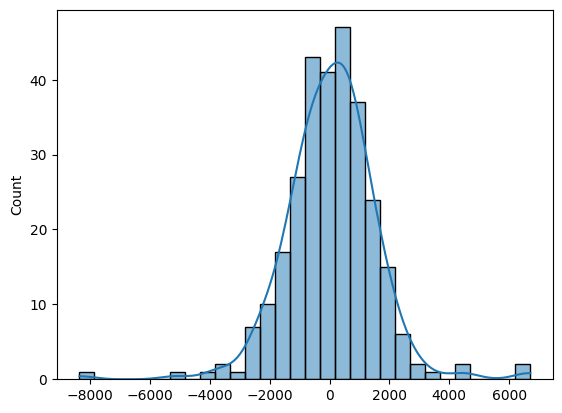

In [ ]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)

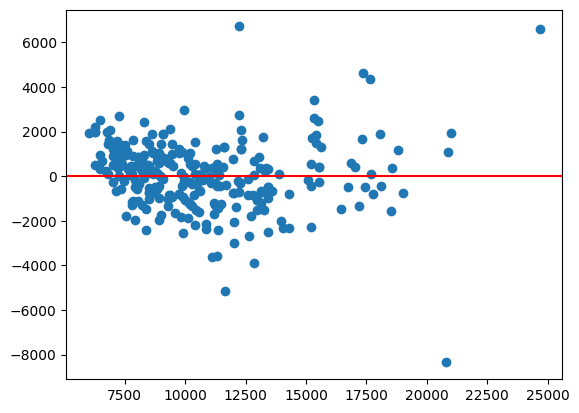

In [ ]:
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')

#Interview Question Answers
#1. What is Normalization & Standardization and how is it helpful?
#Normalization

Normalization scales data between 0 and 1.
Formula: X_new = (X - X_min) / (X_max - X_min)

Used when Data does not follow normal distribution, Distance-based algorithms are used.

#Standardization

Transforms data to:
Mean = 0
Standard deviation = 1

Formula:Z = (X - mean) / standard deviation

Used when: Features have different scales,Applying Ridge/Lasso regression,Applying gradient descent methods,

Benefits:Improves model performance,Faster convergence, Prevents large-scale variables dominating the model,Required for regularization methods


##Q2. Techniques to Address Multicollinearity
Methods:
1. Remove Highly Correlated Variables
Example: If two variables have correlation > 0.9, remove one.

2. Use VIF
VIF > 10 indicates high multicollinearity

3. Apply Ridge Regression
Ridge reduces coefficient variance.

4. Apply PCA:Principal Component Analysis transforms correlated variables into independent components.

5. Increase Dataset Size: Sometimes more observations reduce instability.

1. Interview Question Answers
Q1. What is Normalization & Standardization and how is it helpful?

#Normalization
scales data between 0 and 1:
X_new = (X - X_min) / (X_max - X_min)
It is used when Data does not follow normal distribution,Distance-based algorithms are used

#Standardization:
Transforms data to
Mean = 0
Standard deviation = 1
Z = (X - mean) / standard deviation

it is used when Features have different scales, Applying Ridge/Lasso regression
,Applying gradient descent methods

Benefits is that it Improves model performance, Faster convergence, Prevents large-scale variables dominating the model, Required for regularization methods

Q2. Techniques to Address Multicollinearity
there are multiple  methods:
1. Remove Highly Correlated Variables: If two variables have correlation > 0.9, remove one.

2. Use VIF:VIF > 10 indicates high multicollinearity
3. Apply Ridge Regression: Ridge reduces coefficient variance.

4. Apply PCA: Principal Component Analysis transforms correlated variables into independent components.

5. Increase Dataset Size: Sometimes more observations reduce instability.

